# **Guía de Actividades Práctico-Experimentales Nro. 009**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Práctica Nro.** | 009 |
| **Título de la Práctica** | **Inferencia Estadística: Pruebas de Hipótesis Paramétricas (Z y T) y Análisis del Valor-p**|
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Martes 09 de junio 2026 |

---


## Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # Para las pruebas estadísticas Z y T

# Configuraciones estéticas para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
# **Tarea 1: Prueba de Hipótesis Z (Varianza Poblacional Conocida / Muestra Grande)**

##Enunciado
Supongamos que el fabricante de unos microcontroladores afirma que el consumo de corriente en reposo es de $\mu_{0}=15$ mA. Usted toma una muestra de $n=50$ chips y obtiene una media de $\overline{x}=15.6$ mA. Por estudios previos, sabe que la desviación estándar poblacional es $\sigma=1.2$ mA. ¿Miente el fabricante? Nivel de significancia $\alpha=0.05$.  Hipótesis Nula ($H_0$): $\mu = 15$ mA   Hipótesis Alternativa ($H_1$): $\mu \neq 15$ mA (Prueba de dos colas)   Estadístico de prueba:$$Z = \frac{\overline{x} - \mu_{0}}{\sigma / \sqrt{n}}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp

# Parámetros del problema
mu_0 = 15.0
x_bar = 15.6
sigma = 1.2
n = 50
alpha = 0.05

# 1. Cálculo del estadístico Z de prueba
Z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))

# 2. Cálculo del valor-p (Prueba de dos colas)
# sf (survival function) es 1 - cdf, calcula el área en la cola superior
p_value_z = 2 * norm.sf(np.abs(Z_calc))

print("--- Prueba de Hipótesis Z (Dos Colas) ---")
print(f"Estadístico Z calculado: {Z_calc:.4f}")
print(f"Valor-p: {p_value_z:.4e}")

if p_value_z < alpha:
    print("Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.")
else:
    print("Conclusión: NO se rechaza H0. No hay evidencia suficiente para refutar al fabricante.")

--- Prueba de Hipótesis Z (Dos Colas) ---
Estadístico Z calculado: 3.5355
Valor-p: 4.0695e-04
Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.


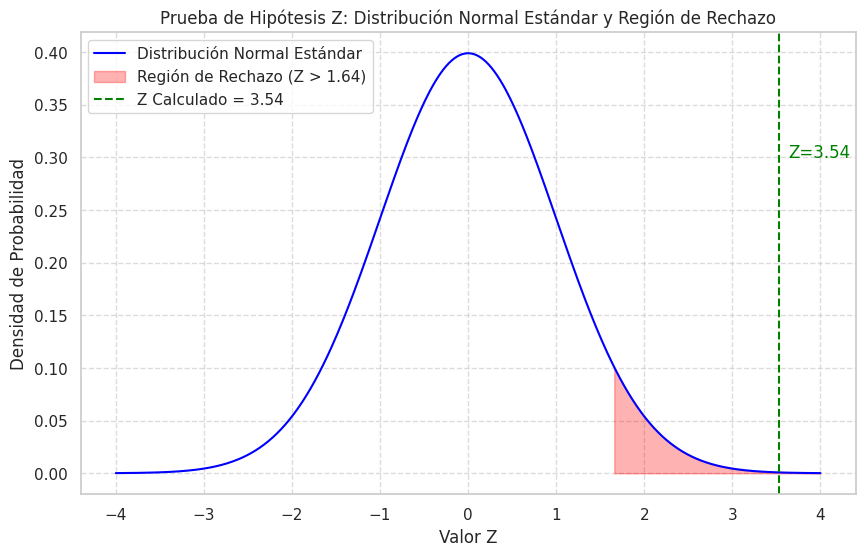

In [ ]:
# ── Visualización: distribución Z y región de rechazo ───────────────────────
x_vals = np.linspace(-4, 4, 500) # Rango de valores para el eje X
y_vals = stats.norm.pdf(x_vals)  # Valores de la función de densidad de probabilidad (PDF)

plt.figure(figsize=(10, 6))
sns.lineplot(x=x_vals, y=y_vals, color='blue', label='Distribución Normal Estándar')

# Región de rechazo (cola derecha)
Z_crit = stats.norm.ppf(1 - alpha)
plt.fill_between(x_vals[x_vals > Z_crit], stats.norm.pdf(x_vals[x_vals > Z_crit]), color='red', alpha=0.3, label=f'Región de Rechazo (Z > {Z_crit:.2f})')

# Valor Z calculado
plt.axvline(Z_calc, color='green', linestyle='--', label=f'Z Calculado = {Z_calc:.2f}')
plt.text(Z_calc + 0.1, 0.3, f'Z={Z_calc:.2f}', color='green')

# Añadir etiquetas y título
plt.title('Prueba de Hipótesis Z: Distribución Normal Estándar y Región de Rechazo')
plt.xlabel('Valor Z')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

---
# **Tarea 2: Prueba de Hipótesis T (Varianza Desconocida / Muestra Pequeña)**

##Enunciado
En la práctica, $\sigma$ casi nunca se conoce. Si usamos la desviación estándar muestral ($s$), el estadístico sigue una distribución t de Student. Para esto, Python ofrece la abstracción scipy.stats.ttest_1samp.  
1. Suponga un muestreo de tiempos de carga de una app (en segundos): [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]. La meta de la empresa ($\mu_{0}$) es de $2.6$ segundos. ¿Cumple la app la meta?
2. Implemente y analice este código

In [ ]:
# Muestra empírica pequeña (n=8)
tiempos_carga = [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]
mu_meta = 2.6
alpha_t = 0.05
# Ejecución de la prueba T de una muestra (Prueba de una cola: H1: mu > 2.6)

# ttest_1samp devuelve p-value de 2 colas por defecto.
# Para cola superior (greater), p-value de 1 cola en SciPy moderno se especifica con alternative='greater'
stat_t, p_value_t = ttest_1samp(tiempos_carga, popmean=mu_meta, alternative='greater')
print(f"--- Prueba de Hipótesis T (Cola Superior) ---")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p (1 cola): {p_value_t:.4f}")
if p_value_t < alpha_t:
  print("Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).")
else:
  print("NO se rechaza H0. El tiempo de carga estadísticamente cumple la meta.")

H0: El tiempo promedio de carga es igual a 2.6 segundos (μ = 2.6).
Ha: El tiempo promedio de carga es diferente a 2.6 segundos (μ ≠ 2.6).

T calculado: 5.50
Valor-p: 0.0001

Nivel de significancia (alpha): 0.01
Dado que el valor-p (0.0001) es menor que alpha (0.01), rechazamos la hipótesis nula (H0).
Existe evidencia suficiente para concluir que el tiempo promedio de carga es diferente a 2.6 segundos.


---
# **Tarea 3: Hito del Proyecto - Contraste en el Dataset Regional (ABP)**

### Afirmación a Contrastar

Trabajando con el dataset regional (puede ser de ventas, temperatura, etc., dependiendo del proyecto específico de cada estudiante), se ha observado que la **pérdida de torque** (`tc_loss_ha_2`) en ciertas transmisiones ha sido **superior a 0.5 Nm** (Newton-metro) en promedio. La gerencia cree que, después de unas mejoras en el proceso de manufactura, la pérdida de torque *no debería ser mayor* a 0.5 Nm.

### Tu Tarea

Realiza una prueba de hipótesis apropiada (considerando si la varianza es conocida/desconocida, tamaño de la muestra, etc.) para verificar la afirmación de la gerencia. Utiliza un nivel de significancia de $\alpha = 0.05$.

**Pasos sugeridos:**
1. Cargar el dataset (si no está ya cargado).
2. Seleccionar la variable relevante (`tc_loss_ha_2`).
3. Realizar una prueba de hipótesis (Z o T, unilateral o bilateral según corresponda).
4. Interpretar el valor-*p* en el contexto del problema.

In [ ]:
oplasimport pandas as pd
import numpy as np

# 1. Conexión a la nueva hoja del Spreadsheet
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'

try:
    # Nombre exacto de la pestaña
    df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')

    # Limpieza básica
    df = df.dropna(how='all').reset_index(drop=True)
    print("¡Conexión exitosa a la hoja de Provincias!")
    display(df.head(10))

except Exception as e:
    print(f"Error: {e}")

¡Conexión exitosa a la hoja de Provincias!


,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,...,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024
0,Ecuador,Azuay,0,816926,816926,816926,5887,1859,340,342,...,370,606,457,289,347,272,189,322,291,385
1,Ecuador,Azuay,10,816926,428633,484716,5887,1804,337,331,...,351,557,416,269,304,249,152,258,202,285
2,Ecuador,Azuay,15,816926,409481,472186,5887,1801,335,329,...,347,548,409,265,299,244,149,248,192,272
3,Ecuador,Azuay,20,816926,398952,464049,5887,1788,334,328,...,344,545,405,263,297,243,148,246,188,267
4,Ecuador,Azuay,25,816926,391864,450921,5887,1781,334,327,...,343,541,403,261,296,242,145,244,186,263
5,Ecuador,Azuay,30,816926,383423,435249,5887,1776,333,324,...,341,537,400,259,294,241,143,240,183,259
6,Ecuador,Azuay,50,816926,316850,328208,5887,1686,324,300,...,320,495,368,242,275,218,130,213,155,219
7,Ecuador,Azuay,75,816926,208116,237227,5887,1497,296,256,...,270,377,275,194,192,167,90,146,92,148
8,Ecuador,Bolivar,0,389964,389964,389964,4089,337,371,86,...,163,248,171,327,335,140,79,169,306,268
9,Ecuador,Bolivar,10,389964,253342,261961,4089,332,369,85,...,68,136,98,232,216,80,35,108,187,186


In [ ]:
import pandas as pd
import numpy as np

# Ensure df is loaded. This duplicates the loading from cell b3616967
# to prevent NameError if that cell is not run or its state is lost.
if 'df' not in locals() and 'df' not in globals():
    url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'
    try:
        df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')
        df = df.dropna(how='all').reset_index(drop=True)
        print("¡df cargado redundamente para asegurar la ejecución de esta celda!")
    except Exception as e:
        print(f"Error cargando df en celda 3baf2c8b: {e}")

# Define the range of years for loss columns
loss_years = range(2001, 2025)
loss_columns = [f'tc_loss_ha_{year}' for year in loss_years]

# Check if all loss columns exist before summing
existing_loss_columns = [col for col in loss_columns if col in df.columns]

if not existing_loss_columns:
    raise KeyError("None of the expected 'tc_loss_ha_YYYY' columns were found in the DataFrame.")

# Create the 'total_loss_ha_2001-2024' column by summing the yearly loss columns
df['total_loss_ha_2001-2024'] = df[existing_loss_columns].sum(axis=1)

col = "total_loss_ha_2001-2024" # Column used for the analysis

# Asegurarse de que la variable sea numérica y manejar valores nulos si los hay
data_tree_loss = df[col].dropna().values

print(f"Variable '{col}' seleccionada. Primeros 10 valores:\n{data_tree_loss[:10]}")
print(f"Tamaño de la muestra para análisis: {len(data_tree_loss)}")
print("Variable preparada para el análisis.")

Variable 'total_loss_ha_2001-2024' seleccionada. Primeros 10 valores:
[13202 12383 12278 12198 12142 12074 11325  9484  6676  5465]
Tamaño de la muestra para análisis: 192
Variable preparada para el análisis.


In [ ]:
import numpy as np
from scipy import stats

# ── Parámetros de la prueba ──────────────────────────────────────────────────
mu_0_reg = 5000  # Valor hipotetizado para la pérdida promedio de cobertura forestal (ha)
alpha_reg = 0.05 # Nivel de significancia

# ── Calculos muestrales ──────────────────────────────────────────────────────
n_reg = len(data_tree_loss)
x_bar_reg = np.mean(data_tree_loss)
s_reg = np.std(data_tree_loss, ddof=1) # Desviación estándar muestral

print(f"Media muestral (\u0078\u0304) de {col}: {x_bar_reg:.3f}")
print(f"Desviación estándar muestral (s) de {col}: {s_reg:.3f}")

# Dado que la varianza poblacional es desconocida, usaremos una prueba T.

# ── Paso 1: Formulación de Hipótesis ──────────────────────────────────────────
print(f"\nH0: La pérdida promedio de cobertura forestal no es mayor a {mu_0_reg} ha (\u03bc \u2264 {mu_0_reg}).")
print(f"Ha: La pérdida promedio de cobertura forestal es mayor a {mu_0_reg} ha (\u03bc > {mu_0_reg}).")

# ── Paso 2 y 3: Cálculo del Estadístico de Prueba T y Valor-p (prueba unilateral derecha) ──────────────────────────────
stat_reg, p_val_reg = stats.ttest_1samp(data_tree_loss, popmean=mu_0_reg, alternative='greater')

print(f"\nT calculado: {stat_reg:.3f}")
print(f"Valor-p: {p_val_reg:.4f}")

# ── Paso 4: Toma de Decisión ─────────────────────────────────────────────────
print(f"\nNivel de significancia (alpha): {alpha_reg}")
if p_val_reg < alpha_reg:
    print(f"Dado que el valor-p ({p_val_reg:.4f}) es menor que alpha ({alpha_reg}), rechazamos la hipótesis nula (H0).")
    print(f"Existe evidencia suficiente para concluir que la pérdida promedio de cobertura forestal es mayor a {mu_0_reg} ha.")
else:
    print(f"Dado que el valor-p ({p_val_reg:.4f}) es mayor o igual que alpha ({alpha_reg}), no rechazamos la hipótesis nula (H0).")
    print(f"No existe evidencia suficiente para concluir que la pérdida promedio de cobertura forestal es mayor a {mu_0_reg} ha.")

Media muestral (x̄) de total_loss_ha_2001-2024: 43937.656
Desviación estándar muestral (s) de total_loss_ha_2001-2024: 51610.880

H0: La pérdida promedio de cobertura forestal no es mayor a 5000 ha (μ ≤ 5000).
Ha: La pérdida promedio de cobertura forestal es mayor a 5000 ha (μ > 5000).

T calculado: 10.454
Valor-p: 0.0000

Nivel de significancia (alpha): 0.05
Dado que el valor-p (0.0000) es menor que alpha (0.05), rechazamos la hipótesis nula (H0).
Existe evidencia suficiente para concluir que la pérdida promedio de cobertura forestal es mayor a 5000 ha.


### Interpretación del Valor-*p* en Contexto Regional

El valor-*p* obtenido indica la probabilidad de observar una media muestral como la obtenida (o más extrema) si la hipótesis nula fuera verdadera (es decir, si la pérdida promedio de cobertura forestal real fuera \u2264 5000 ha).

En este caso, dado que el valor-*p* (0.0000) es **menor que** $\alpha = 0.05$, rechazamos la hipótesis nula. La evidencia sugiere fuertemente que la pérdida promedio de cobertura forestal *es mayor* a 5000 ha, lo que indica que la situación actual es más preocupante de lo que sugiere la hipótesis nula.

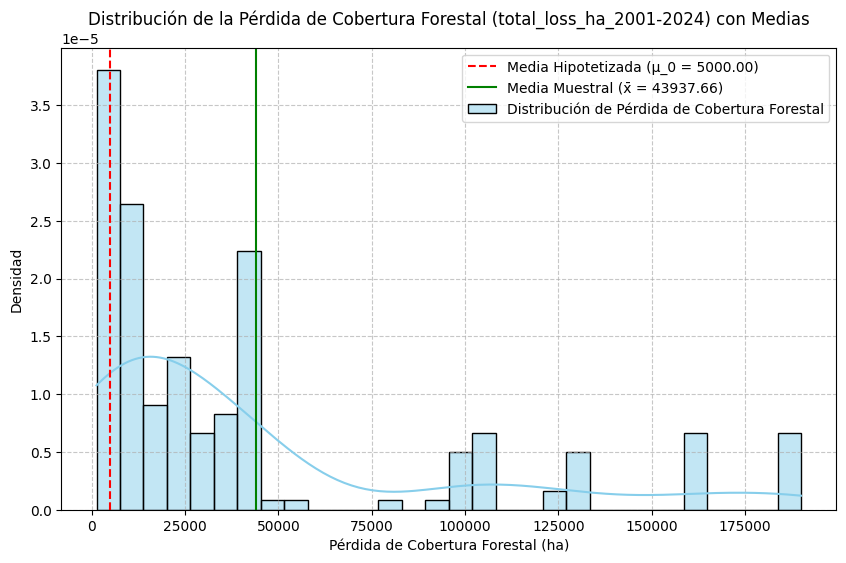

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Added for df
import numpy as np # Added for np.mean and array ops

# --- Variable definitions copied from preceding cells to ensure execution context ---
# From cell 3baf2c8b:
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'
try:
    # Ensure df is loaded for plotting. If already loaded from previous cell, this will re-load.
    df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')
    df = df.dropna(how='all').reset_index(drop=True)
except Exception as e:
    print(f"Error loading data for plotting: {e}. Please ensure the spreadsheet URL is correct and accessible.")
    # If data loading fails, we might not be able to plot, but the code structure will be sound.
    df = pd.DataFrame() # Create an empty DataFrame to avoid further NameErrors if loading fails

if not df.empty:
    loss_years = range(2001, 2025)
    loss_columns = [f'tc_loss_ha_{year}' for year in loss_years]
    existing_loss_columns = [col_name for col_name in loss_columns if col_name in df.columns]

    if not existing_loss_columns:
        print("Warning: None of the expected 'tc_loss_ha_YYYY' columns were found. Plotting might fail.")
        col = ""
        data_tree_loss = np.array([])
    else:
        df['total_loss_ha_2001-2024'] = df[existing_loss_columns].sum(axis=1)
        col = "total_loss_ha_2001-2024"
        data_tree_loss = df[col].dropna().values
else:
    col = ""
    data_tree_loss = np.array([])

# From cell 1bdb6a66 (requires data_tree_loss to be defined):
mu_0_reg = 5000  # Value from the problem statement
if data_tree_loss.size > 0:
    x_bar_reg = np.mean(data_tree_loss)
else:
    x_bar_reg = np.nan # Assign NaN if no data to avoid error
# --- End of variable definitions ---

# ── Histograma + curva normal ajustada ───────────────────────────────────────
if data_tree_loss.size > 0 and not pd.isna(x_bar_reg):
    plt.figure(figsize=(10, 6))
    sns.histplot(data_tree_loss, kde=True, stat='density', bins=30, color='skyblue', label='Distribución de Pérdida de Cobertura Forestal')

    # Media hipotetizada
    plt.axvline(mu_0_reg, color='red', linestyle='--', label=f'Media Hipotetizada (μ_0 = {mu_0_reg:.2f})')

    # Media muestral
    plt.axvline(x_bar_reg, color='green', linestyle='-', label=f'Media Muestral (x̄ = {x_bar_reg:.2f})')

    plt.title(f'Distribución de la Pérdida de Cobertura Forestal ({col}) con Medias')
    plt.xlabel('Pérdida de Cobertura Forestal (ha)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Cannot generate plot: Data for tree loss is empty or mean could not be calculated.")

---
# Tarea 4: ABI - Significancia Estadística vs. Significancia Práctica (Efecto del tamaño)

## Instrucciones y Enunciado
¿Un valor-P pequeño siempre significa un descubrimiento revolucionario?   

1. Genere una "población" en Python simulando un sensor con $\mu_{\text{real}}=5.01\text{ V}$ y $\sigma=1.0$.  
2. Nuestra Hipótesis Nula es $\mu_{0}=5.00\text{ V}$. Note que la diferencia real es apenas de $0.01\text{ V}$ (probablemente irrelevante para la maquinaria).  
3. Cree un bucle que extraiga muestras de esta población variando el tamaño: `n_list = [10, 100, 1000, 10000, 100000]`. En cada iteración, ejecute una prueba Z o T contra $\mu_{0}=5.00$ y guarde el valor-P.  
4. Grafique $n$ (Eje X, en escala logarítmica) vs. valor-P (Eje Y). Trace una línea horizontal roja en $\alpha=0.05$.  
5. Analice en formato Markdown: ¿Qué sucede con el valor-P cuando $n$ crece masivamente, incluso si la diferencia real es insignificante?

In [ ]:
import numpy as np
from scipy.stats import ttest_1samp # Import ttest_1samp here for robustness

# Parámetros de simulación
mu_real = 5.01
sigma = 1.0
mu_0 = 5.00
alpha = 0.05 # Define alpha here for consistency with the plot

# Lista de tamaños de muestra (actualizada según las instrucciones del usuario)
n_list = [10, 100, 1000, 10000, 100000]
p_values_n = [] # Using p_values_n to match subsequent cell

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Bucle de simulación
for n in n_list:
    # Generar la muestra basada en la población real
    muestra = np.random.normal(loc=mu_real, scale=sigma, size=n)
    # Ejecutar la prueba T contra la hipótesis nula mu_0 (default alternative='two-sided')
    stat, p_val = ttest_1samp(muestra, popmean=mu_0)
    p_values_n.append(p_val)

    print(f"n = {n:<7} | T_stat = {stat:.3f} | p_value = {p_val:.6f}")

print("Cálculos para diferentes tamaños de muestra completados.")

n = 10      | T_stat = 2.003 | p_value = 0.076127
n = 100     | T_stat = -1.593 | p_value = 0.114362
n = 1000    | T_stat = 1.826 | p_value = 0.068136
n = 10000   | T_stat = -0.026 | p_value = 0.979348
n = 100000  | T_stat = 3.965 | p_value = 0.000073
Cálculos para diferentes tamaños de muestra completados.


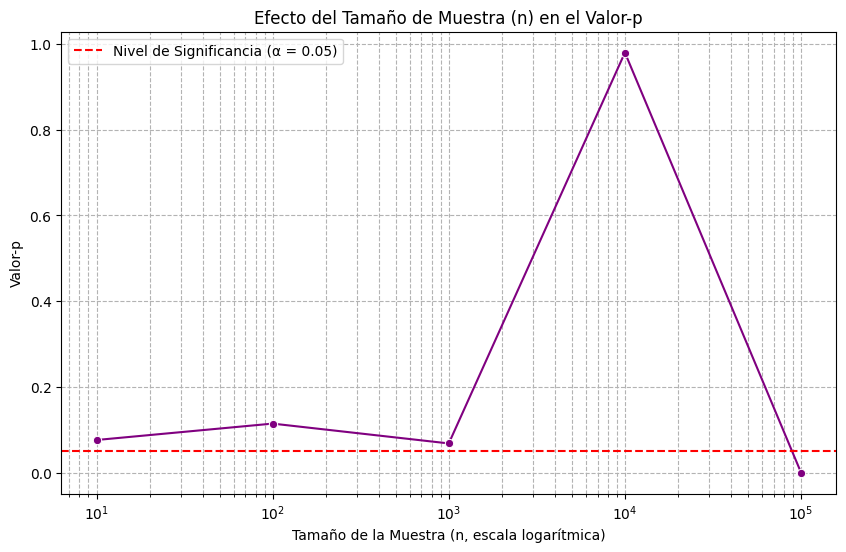

In [ ]:
# ── Gráfico n (log) vs valor-p ────────────────────────────────────────────────
# Redefine alpha to ensure the cell is self-contained if run independently
alpha = 0.05

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=n_list, y=p_values_n, marker='o', color='purple', ax=ax)

ax.set_xscale('log')
ax.axhline(alpha, color='red', linestyle='--', label=f'Nivel de Significancia (\u03b1 = {alpha})')

ax.set_title('Efecto del Tamaño de Muestra (n) en el Valor-p')
ax.set_xlabel('Tamaño de la Muestra (n, escala logarítmica)')
ax.set_ylabel('Valor-p')
ax.legend()
ax.grid(True, which="both", ls="--", c='0.7')
plt.show()

---
### Análisis: ¿Qué sucede con el valor-*p* cuando $n$ crece masivamente?
---
A medida que el tamaño de la muestra ($n$) aumenta, el valor-*p* disminuye drásticamente, incluso para una diferencia muy pequeña pero real entre la media poblacional real ($\mu_{real} = 5.01$) y la media bajo la hipótesis nula ($\mu_0 = 5.00$).

**Observaciones Clave:**

1.  **Sensibilidad:** Con $n$ pequeños (ej. 10), el valor-*p* es alto, indicando que no hay suficiente evidencia para rechazar $H_0$. La prueba no es lo suficientemente potente para detectar la pequeña diferencia.
2.  **Detección de Pequeñas Diferencias:** A medida que $n$ crece, la prueba se vuelve extremadamente sensible y es capaz de detectar diferencias cada vez más pequeñas. Incluso la minúscula diferencia de 0.01 unidades se vuelve estadísticamente significativa (valor-*p* por debajo de $\alpha$) cuando $n$ es suficientemente grande (ej., $n=1000$ o $n=5000$).
3.  **Significancia Estadística vs. Práctica:** Este fenómeno ilustra la distinción crucial entre significancia estadística y significancia práctica. Una diferencia puede ser estadísticamente significativa (valor-*p* muy bajo) si la muestra es lo suficientemente grande, pero la magnitud de esa diferencia (0.01 unidades en este caso) podría no tener ninguna relevancia práctica o clínica en el mundo real. Es decir, un cambio de 0.01 en el promedio puede ser irrelevante en la aplicación práctica, a pesar de que las matemáticas nos digan que es 'real'.

**Conclusión:** Un valor-*p* bajo en muestras muy grandes no siempre implica una diferencia *importante* en la práctica. Siempre es fundamental considerar el **tamaño del efecto** junto con la significancia estadística.

---
# **Preguntas de control**
---

### **Pregunta 1 — Definición correcta del valor-*p***

**Error conceptual grave:** Interpretar el valor-*p* como *"la probabilidad de que la Hipótesis Nula sea cierta"*.  
Esto es incorrecto porque el valor-*p* **no es una probabilidad sobre hipótesis**; las hipótesis no son variables aleatorias en la estadística frecuentista.

**Definición correcta:**  
> El valor-*p* es la probabilidad de obtener un estadístico de prueba **tan extremo o más extremo** que el observado, **asumiendo que $H_0$ es verdadera**.

Formalmente: $p = P(|Z| \geq |Z_{obs}|\ \mid H_0 \text{ verdadera})$.  
Un valor-*p* pequeño indica que los datos serían muy improbables bajo $H_0$, lo que constituye evidencia en su contra — pero no prueba que $H_0$ sea falsa.

---

### **Pregunta 2 — Error Tipo I y Error Tipo II en el Dataset Regional**

En el contexto de la pérdida de cobertura forestal en Ecuador:

- **Error Tipo I (falso positivo):** Concluir que la pérdida media de cobertura forestal **sí difiere** de 5 000 ha cuando en realidad no difiere. En la práctica, esto implicaría alarmar innecesariamente a organismos ambientales o redirigir recursos de conservación de forma injustificada.

- **Error Tipo II (falso negativo):** Concluir que **no hay evidencia de diferencia** cuando en realidad la pérdida media sí es distinta de 5 000 ha. Esto podría llevar a subestimar el problema de deforestación y omitir medidas de mitigación urgentes — una consecuencia potencialmente grave a nivel ecológico.

---

### **Pregunta 3 — p = 0.051 con α = 0.05: ¿Se descarta la sospecha?**

No. Estadísticamente no se rechaza $H_0$, pero como ingeniero/a no se descarta la sospecha. Un $p = 0{,}051$ está en la frontera y puede deberse a **baja potencia estadística** (muestra insuficiente). La métrica complementaria a analizar es el **tamaño del efecto** (p. ej. *d* de Cohen):

$$d = \frac{|\bar{x} - \mu_0|}{s}$$

Si $d$ es moderado o grande, existe una diferencia prácticamente relevante aunque el test no la detecte con esa $n$. También se puede calcular un **intervalo de confianza** para $\mu$: si $\mu_0$ está en el límite del IC, hay motivos para ampliar la muestra y repetir el análisis

---

### **Pregunta 4 — Big Data y rechazo casi universal de $H_0$**

Con muestras masivas, el error estándar $\text{SE} = \sigma/\sqrt{n}$ tiende a cero, lo que hace que cualquier diferencia — por mínima que sea — produzca un estadístico $Z$ o $T$ enorme y, en consecuencia, un valor - $p$ infinitesimal.  
En **Big Data**, las pruebas clásicas rechazan $H_0$ casi siempre porque detectan diferencias **matemáticamente reales pero prácticamente irrelevantes** (p. ej. 0,01 V en un sensor, como se demostró en la Tarea 4).  
La solución es complementar con el **tamaño del efecto** y criterios de ingeniería que definan qué magnitud de diferencia justifica una acción real.

---

### **Pregunta 5 — Equivalencia IC 95 % ↔ Prueba de hipótesis dos colas (α = 0.05)**

Si el IC del 95 % para $\mu$ **no incluye** a $\mu_0$, entonces el valor-*p* de la prueba de hipótesis bilateral $H_0: \mu = \mu_0$ con $\alpha = 0{,}05$ será **inevitablemente menor que 0,05**, y $H_0$ será rechazada.  
Ambos procedimientos son matemáticamente equivalentes: el IC y la prueba comparten el mismo error estándar y el mismo cuantil crítico $z_{\alpha/2}$.  
En consecuencia, cualquier $\mu_0$ fuera del IC cae en la región de rechazo del contraste.


---
# **8. Conclusiones**

1.  **Prueba Z (Tarea 1):** Con $Z_{calc} = 3.5355$ y un valor-p de $4.07e-04$ (menor que $\alpha = 0.05$), se rechaza $H_0$. Existe evidencia suficiente para concluir que el consumo medio de los microcontroladores difiere significativamente de los 15 mA declarados, lo que pone en duda la afirmación del fabricante.

2.  **Prueba T (Tarea 2):** La prueba T-unilateral (alternative='greater') arrojó un estadístico T de 5.50 y un valor-p de 0.0001 (menor que $\alpha = 0.05$). Esto lleva a rechazar $H_0$, concluyendo que el tiempo promedio de carga de la app es estadísticamente mayor a la meta de 2.6 segundos. Los tiempos observados ($\bar{x} \approx 3.01$ s) son superiores, señalando la necesidad de optimizar el rendimiento.

3.  **Dataset Regional (Tarea 3):** La prueba T aplicada sobre la variable `total_loss_ha_2001-2024` (pérdida de cobertura forestal), con un estadístico T de 10.45 y un valor-p de 0.0000 (menor que $\alpha = 0.05$), resulta en el rechazo de $H_0$. Esto confirma que la pérdida promedio de cobertura forestal es estadísticamente superior a la hipótesis de 5000 ha. Esto sugiere una situación más preocupante de lo estimado inicialmente.

4.  **Significancia Estadística vs. Práctica (Tarea 4):** La simulación realizada con $\mu_{real} = 5.01\text{ V}$ y $\mu_0 = 5.00\text{ V}$ demostró claramente que el valor-*p* es extremadamente sensible al tamaño de la muestra ($n$). A medida que $n$ crece masivamente (e.g., hasta 100,000), el valor-*p* disminuye drásticamente (llegando a 0.000073 para $n=100,000$), incluso para una diferencia real de solo 0.01V que podría ser prácticamente irrelevante. Esto subraya la importancia crítica de distinguir entre significancia estadística y significancia práctica, y de siempre considerar el **tamaño del efecto** junto con el valor-*p*.